In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('loan_approval_dataset.csv')

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
C:\Users\user\AppData\Local\Temp\ipykernel_19780\3730472393.py:1: SyntaxWarning: invalid escape sequence '\l'
  df = pd.read_csv('ML\loan_approval_dataset.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'ML\\loan_approval_dataset.csv'

In [ ]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [ ]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [ ]:
X = df.drop(columns='Loan_Approved')
y = df.Loan_Approved

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(
    X,y,
    random_state=42,
    train_size=0.8
)

In [ ]:
X.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [ ]:
num_cols = X.select_dtypes(include='number').columns
obj_cols = X.select_dtypes(include='object').columns

<Axes: >

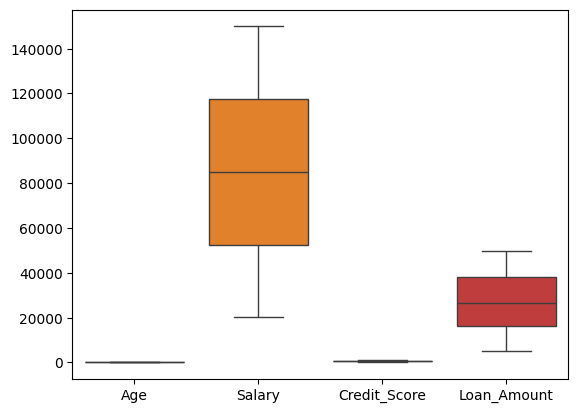

In [ ]:
sns.boxplot(X[num_cols])

In [ ]:
X[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [ ]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
scaling  = MinMaxScaler()
# model = LogisticRegression(penalty='l1',solver='liblinear')
model = LogisticRegression(penalty=None)

In [ ]:
# model.fit(xtrain,ytrain)

In [ ]:
#Xtrain
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
# xtrain[obj_cols] = encoder.fit_transform(xtrain[obj_cols])
encoded_values = encoder.fit_transform(xtrain[obj_cols])
encoded_columns = encoder.get_feature_names_out()
xtrain[encoded_columns] = encoded_values
xtrain.drop(columns=obj_cols,inplace=True)

In [ ]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
#Xtest
xtest[num_cols] = scaling.transform(xtest[num_cols])
# xtest[obj_cols] = encoder.fit_transform(xtest[obj_cols])
encoded_values = encoder.transform(xtest[obj_cols])
xtest[encoded_columns] = encoded_values
xtest.drop(columns=obj_cols,inplace=True)

In [ ]:
model.fit(xtrain,ytrain)

LogisticRegression(penalty=None)

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix

In [ ]:
ytrain_pred = model.predict(xtrain)
matrix = confusion_matrix(ytrain,ytrain_pred)

In [ ]:
ytest_pred=model.predict(xtest)

In [ ]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

In [ ]:
precision_score(ytrain,ytrain_pred,pos_label='Yes')

0.5471698113207547

In [ ]:
predicted_yes = np.sum(matrix[:,1])
predicted_no = np.sum(matrix[:,0])

In [ ]:
precision_score(ytrain,ytrain_pred,pos_label='No')

0.5452127659574468

In [ ]:
recall_score(ytrain,ytrain_pred,pos_label='Yes')

0.575682382133995

In [ ]:
recall_score(ytrain,ytrain_pred,pos_label='No')

0.5163727959697733

In [ ]:

accuracy_score(ytrain,ytrain_pred)

0.54625

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(ytrain,ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



In [ ]:
print(classification_report(ytest,ytest_pred))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200

